In [1]:
import gzip
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter, defaultdict

# Calculating and Storing Fragment Lengths

In [8]:
fragmentLen = []
fragmentLenDict = defaultdict(list)

with gzip.open("./query.bed.gz", "rt") as f:
    for line in f:
        cols = line.strip().split('\t')
        Len = int(cols[2]) - int(cols[1])
        if Len > 0:
            fragmentLen.append(Len)
            fragmentLenDict[Len].append((int(cols[1]), int(cols[2])))


# Normalising and Plotting Fragment Lengths

In [10]:
lenCts = Counter(fragmentLen)

len_df = pd.DataFrame(lenCts.items(), columns=["Length", "Count"])
len_df.sort_values("Length", inplace=True)

len_df["Normalized"] = len_df["Count"] / len_df["Count"].sum()


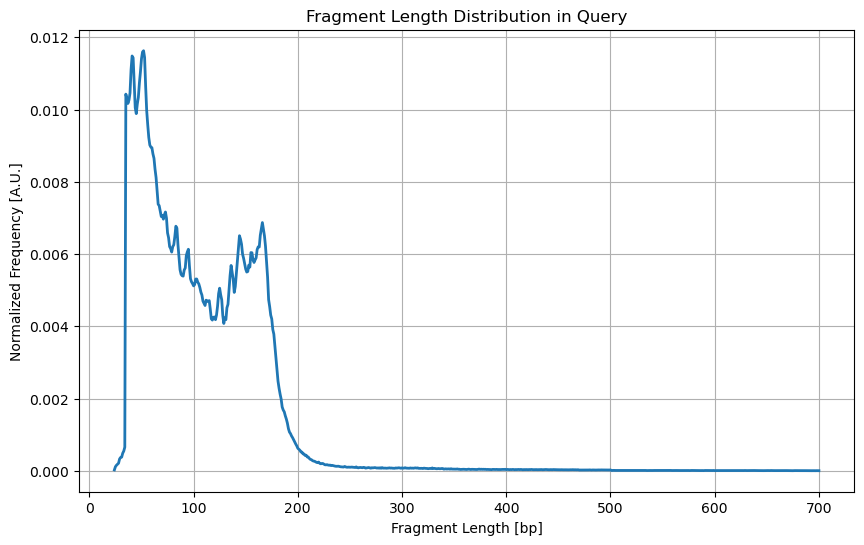

In [15]:
plt.figure(figsize=(10,6))
plt.plot(len_df["Length"], len_df["Normalized"], lw=2)
plt.xlabel("Fragment Length [bp]")
plt.ylabel("Normalized Frequency [A.U.]")
plt.title("Fragment Length Distribution in Query")
plt.grid(True)
plt.show()


# Storing the Reference as a DataFrame

In [16]:
ref_df = pd.read_csv('./reference.hist', sep='\t', names=["Length", "RefNorm"])

# Rescaling the Query

In [27]:
targetCts = {}
targetNum = 10000

refSum = ref_df["RefNorm"].sum()
ref_df["targetCt"] = (ref_df["RefNorm"] / refSum * targetNum).astype(int)

rescaledFragments = []
for i, row in ref_df.iterrows():
    Len = int(row["Length"])
    target = int(row["targetCt"])
    available = fragmentLenDict.get(Len, [])
    if available:
        sampled = available[0:min(len(available),target)]
        rescaledFragments.extend(sampled)

rescaledLengths = [end - start for start, end in rescaledFragments]
rescaledCts = Counter(rescaledLengths)

rescaled_df = pd.DataFrame(rescaledCts.items(), columns=["Length", "Count"])
rescaled_df.sort_values("Length", inplace=True)
rescaled_df["Normalized"] = rescaled_df["Count"] / rescaled_df["Count"].sum()


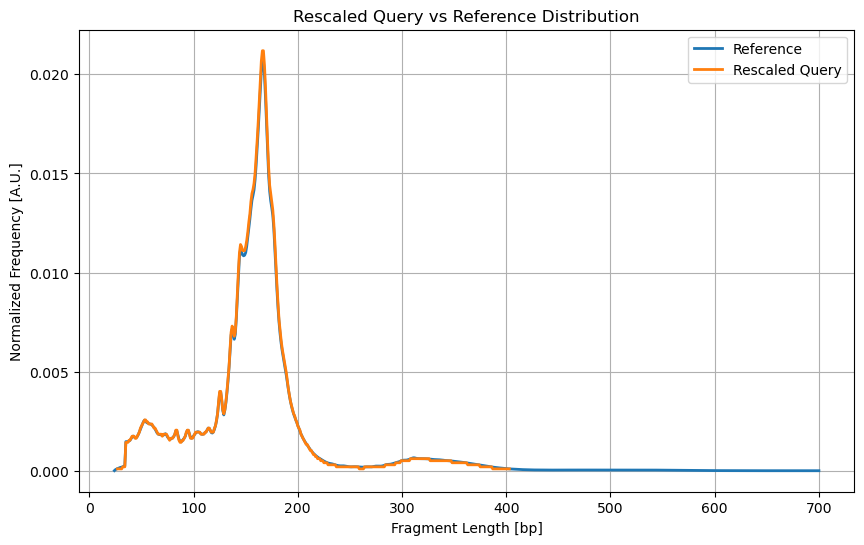

In [30]:
plt.figure(figsize=(10,6))
plt.plot(ref_df["Length"], ref_df["RefNorm"], label="Reference", lw=2)
plt.plot(rescaled_df["Length"], rescaled_df["Normalized"], label="Rescaled Query", lw=2)
plt.xlabel("Fragment Length [bp]")
plt.ylabel("Normalized Frequency [A.U.]")
plt.title("Rescaled Query vs Reference Distribution")
plt.legend()
plt.grid(True)
plt.show()
